## Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import joblib

import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

c:\Users\julia\SY2627\Projects\country_classification_on_wine_reviews\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

print(f"Using {device} device")

Using cpu device


## Loading and preparing the dataset

In [3]:
df = pd.read_csv('input/wine_reviews_cleaned.csv')
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,clean_description
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,aroma include tropical fruit broom brimstone a...
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,this ripe and fruity wine that smooth while st...
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,tart and snappy the flavor lime flesh and rind...
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,pineapple rind lemon pith and orange blossom s...
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,much like the regular bottling from 2012 this ...


In [4]:
df = df[['clean_description', 'country']]
df = df[df['clean_description'].notnull() & df['country'].notnull()]
df.head()

,clean_description,country
0,aroma include tropical fruit broom brimstone a...,Italy
1,this ripe and fruity wine that smooth while st...,Portugal
2,tart and snappy the flavor lime flesh and rind...,US
3,pineapple rind lemon pith and orange blossom s...,US
4,much like the regular bottling from 2012 this ...,US


In [5]:
df['country'].nunique()

43

In [6]:
df = df[df.groupby('country')['country'].transform('count') >= 5]
n_classes = df['country'].nunique()
n_classes

38

In [7]:
label_encoder = LabelEncoder()
df['country_encoded'] = label_encoder.fit_transform(df['country'])

## Train/Validation/Test Split (70/15/15)

In [8]:
# Prepare features and labels
X = df["clean_description"]
y = df["country_encoded"]

In [9]:
# First split: Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,        # 30% for temp (will be split into val + test)
    stratify=y,           # Maintain class distribution
    random_state=42       # Reproducibility
)

# Second split: Val (15%) vs Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,        # 50% of temp = 15% of total
    stratify=y_temp,      # Maintain class distribution
    random_state=42
)

In [ ]:
# Create DataFrames for each split
train_df = pd.DataFrame({
    'clean_description': X_train,
    'country': y_train
})

val_df = pd.DataFrame({
    'clean_description': X_val,
    'country': y_val
})

test_df = pd.DataFrame({
    'clean_description': X_test,
    'country': y_test
})

In [12]:
# Save to CSV
train_df.to_csv('train1.csv', index=False)
val_df.to_csv('val1.csv', index=False)
test_df.to_csv('test1.csv', index=False)

In [13]:
# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3)
)

In [14]:
# Fit on training data and transform all sets
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_val_tfidf = vectorizer.transform(X_val).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

## Building the model

In [15]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], num_classes=n_classes, dropout=0.4):
        super(MLPClassifier, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [16]:
# More robust ReviewDataset class
class ReviewDataset(Dataset):
    def __init__(self, features, labels):
        # Handle features conversion
        if hasattr(features, 'toarray'):  # Sparse matrix
            features = features.toarray()
        elif hasattr(features, 'values'):  # pandas Series/DataFrame
            features = features.values
        self.features = torch.FloatTensor(features)

        # Handle labels conversion
        if hasattr(labels, 'values'):  # pandas Series
            labels = labels.values
        elif hasattr(labels, 'flatten'):  # numpy array
            labels = labels.flatten()
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [17]:
# Create datasets
train_dataset = ReviewDataset(X_train_tfidf, y_train)
val_dataset = ReviewDataset(X_val_tfidf, y_val)
test_dataset = ReviewDataset(X_test_tfidf, y_test)

print(f"  Train dataset: {len(train_dataset):,} samples")
print(f"  Val dataset:   {len(val_dataset):,} samples")
print(f"  Test dataset:  {len(test_dataset):,} samples")

  Train dataset: 90,930 samples
  Val dataset:   19,485 samples
  Test dataset:  19,486 samples


In [18]:
# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Batch size: 64
Batches - Train: 1421, Val: 305, Test: 305


In [19]:
def objective_mlp_tfidf(trial):

    # MLP architecture parameters
    hidden_1 = trial.suggest_int('hidden_1', 128, 512)
    hidden_2 = trial.suggest_int('hidden_2', 64, 256)
    hidden_3 = trial.suggest_int('hidden_3', 32, 128)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)

    # Training parameters
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    l2 = trial.suggest_float("l2", 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    epochs = trial.suggest_int('epochs', 5, 20)

    # Create TF-IDF features
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 3),
    )

    X_train_vec = vectorizer.fit_transform(X_train).toarray()
    X_val_vec = vectorizer.transform(X_val).toarray()

    # Create datasets and dataloaders
    train_dataset = ReviewDataset(X_train_vec, y_train)
    val_dataset = ReviewDataset(X_val_vec, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create model
    model = MLPClassifier(
        input_dim=5000,
        hidden_dims=[hidden_1, hidden_2, hidden_3],
        dropout=dropout
    ).to(device)

    # Loss and optimizer
    class_counts = np.bincount(y_train)
    class_weights = torch.FloatTensor([1.0 / c for c in class_counts]).to(device)
    class_weights = class_weights * len(class_weights) / class_weights.sum()

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Train for limited epochs (for speed)
    num_epochs = 10
    best_val_f1 = 0
    patience = 3
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                _, preds = outputs.max(1)
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(labels.cpu().tolist())

        val_f1 = f1_score(all_labels, all_preds, average = 'weighted')

        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_f1

In [20]:
# Run optimization
study_mlp_tfidf = optuna.create_study(
    direction='maximize',
    study_name='mlp_tfidf_optuna',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_mlp_tfidf.optimize(
    objective_mlp_tfidf,
    n_trials=10,
    show_progress_bar=True,
    n_jobs=1  # Don't parallelize to avoid GPU conflicts
)

[I 2026-08-24 11:22:38,559] A new study created in memory with name: mlp_tfidf_optuna


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-08-24 11:24:54,509] Trial 0 finished with value: 0.7966451047517917 and parameters: {'hidden_1': 272, 'hidden_2': 247, 'hidden_3': 103, 'dropout': 0.3394633936788146, 'lr': 0.0002051338263087451, 'l2': 4.207053950287936e-06, 'batch_size': 64, 'epochs': 16}. Best is trial 0 with value: 0.7966451047517917.
[I 2026-08-24 11:26:38,400] Trial 1 finished with value: 0.8055194626448873 and parameters: {'hidden_1': 135, 'hidden_2': 251, 'hidden_3': 112, 'dropout': 0.18493564427131048, 'lr': 0.0002310201887845295, 'l2': 5.415244119402541e-06, 'batch_size': 64, 'epochs': 9}. Best is trial 1 with value: 0.8055194626448873.
[I 2026-08-24 11:28:14,676] Trial 2 finished with value: 0.7741524515670073 and parameters: {'hidden_1': 363, 'hidden_2': 90, 'hidden_3': 60, 'dropout': 0.2465447373174767, 'lr': 0.000816845589476017, 'l2': 0.0013826232179369874, 'batch_size': 128, 'epochs': 5}. Best is trial 1 with value: 0.8055194626448873.
[I 2026-08-24 11:29:21,475] Trial 3 finished with value: 0.58

In [21]:
# Print results
print(f"Best Trial: #{study_mlp_tfidf.best_trial.number}")
print(f"Best Validation F1: {study_mlp_tfidf.best_trial.value:.4f}")
print(f"Best Hyperparameters:")
for key, value in study_mlp_tfidf.best_params.items():
    print(f"  {key:15s}: {value}")

Best Trial: #8
Best Validation F1: 0.8170
Best Hyperparameters:
  hidden_1       : 460
  hidden_2       : 184
  hidden_3       : 64
  dropout        : 0.12542334011440948
  lr             : 0.0004187594718900631
  l2             : 1.99863407785289e-05
  batch_size     : 128
  epochs         : 12


In [22]:
# Train final model with best parameters (full training)
# Create TF-IDF features with best params
vectorizer_mlp = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer_mlp.fit_transform(X_train).toarray()
X_val_vec = vectorizer_mlp.transform(X_val).toarray()
X_test_vec = vectorizer_mlp.transform(X_test).toarray()

# Create datasets
train_dataset = ReviewDataset(X_train_vec, y_train)
val_dataset = ReviewDataset(X_val_vec, y_val)
test_dataset = ReviewDataset(X_test_vec, y_test)

batch_size = study_mlp_tfidf.best_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [23]:
# Create model with best architecture
mlp_tfidf_optuna = MLPClassifier(
    input_dim=5000,
    hidden_dims=[
        study_mlp_tfidf.best_params['hidden_1'],
        study_mlp_tfidf.best_params['hidden_2'],
        study_mlp_tfidf.best_params['hidden_3']
    ],
    dropout=study_mlp_tfidf.best_params['dropout']
).to(device)

In [24]:
# Loss and optimizer
class_counts = np.bincount(y_train)
class_weights = torch.FloatTensor([1.0 / c for c in class_counts]).to(device)
class_weights = class_weights * len(class_weights) / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    mlp_tfidf_optuna.parameters(),
    lr=study_mlp_tfidf.best_params['lr'],
    weight_decay=1e-5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [26]:
# Training loop
num_epochs = 30
best_val_f1 = 0
patience = 7
patience_counter = 0

history = {'train_loss': [], 'val_f1': []}

for epoch in range(num_epochs):
    # Training
    mlp_tfidf_optuna.train()
    train_loss = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = mlp_tfidf_optuna(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    mlp_tfidf_optuna.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = mlp_tfidf_optuna(features)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    history['train_loss'].append(train_loss)
    history['val_f1'].append(val_f1)

    scheduler.step(val_f1)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(mlp_tfidf_optuna.state_dict(), 'mlp_tfidf_optuna_best.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

Epoch  1/30 | Loss: 1.3898 | Val F1: 0.7271
Epoch  2/30 | Loss: 0.7467 | Val F1: 0.7820
Epoch  3/30 | Loss: 0.4109 | Val F1: 0.7869
Epoch  4/30 | Loss: 0.2853 | Val F1: 0.8033
Epoch  5/30 | Loss: 0.2185 | Val F1: 0.8148
Epoch  6/30 | Loss: 0.1611 | Val F1: 0.8141
Epoch  7/30 | Loss: 0.1343 | Val F1: 0.8129
Epoch  8/30 | Loss: 0.1082 | Val F1: 0.8157
Epoch  9/30 | Loss: 0.0991 | Val F1: 0.8132
Epoch 10/30 | Loss: 0.1133 | Val F1: 0.8105
Epoch 11/30 | Loss: 0.0889 | Val F1: 0.8194
Epoch 12/30 | Loss: 0.0791 | Val F1: 0.8190
Epoch 13/30 | Loss: 0.0681 | Val F1: 0.8220
Epoch 14/30 | Loss: 0.0552 | Val F1: 0.8251
Epoch 15/30 | Loss: 0.0454 | Val F1: 0.8241
Epoch 16/30 | Loss: 0.0321 | Val F1: 0.8278
Epoch 17/30 | Loss: 0.0414 | Val F1: 0.8300
Epoch 18/30 | Loss: 0.0431 | Val F1: 0.8258
Epoch 19/30 | Loss: 0.0476 | Val F1: 0.8236
Epoch 20/30 | Loss: 0.0385 | Val F1: 0.8269
Epoch 21/30 | Loss: 0.0348 | Val F1: 0.8222
Epoch 22/30 | Loss: 0.0250 | Val F1: 0.8291
Epoch 23/30 | Loss: 0.0147 | Val

In [27]:
# Load best model
mlp_tfidf_optuna.load_state_dict(torch.load('mlp_tfidf_optuna_best.pth'))
print(f"Best validation F1: {best_val_f1:.4f}")

Best validation F1: 0.8361


In [52]:
best_params = study_mlp_tfidf.best_params

In [54]:
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")

['tfidf_vectorizer.joblib']

In [56]:
torch.save({
    "model_state_dict": mlp_tfidf_optuna.state_dict(),
    "best_params": best_params,
    "input_dim": 5000,
    "best_f1": study_mlp_tfidf.best_value
}, "best_mlp_tfidf.pth")

In [29]:
# Evaluate on test set
def evaluate_mlp(model, loader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average = 'weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average = 'weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average = 'weighted', zero_division=0)
    auc = roc_auc_score(all_labels, all_probs, average = 'weighted', multi_class='ovr')

    return {
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'roc_auc': float(auc)
    }

mlp_tfidf_optuna_train = evaluate_mlp(mlp_tfidf_optuna, train_loader)
mlp_tfidf_optuna_val = evaluate_mlp(mlp_tfidf_optuna, val_loader)
mlp_tfidf_optuna_test = evaluate_mlp(mlp_tfidf_optuna, test_loader)

In [30]:
print(f"Train Set:")
print(f"  Accuracy: {mlp_tfidf_optuna_train['accuracy']:.4f}")
print(f"  F1-Score: {mlp_tfidf_optuna_train['f1']:.4f}")

Train Set:
  Accuracy: 0.9995
  F1-Score: 0.9995


In [31]:
print(f"Validation Set:")
print(f"  Accuracy: {mlp_tfidf_optuna_val['accuracy']:.4f}")
print(f"  F1-Score: {mlp_tfidf_optuna_val['f1']:.4f}")

Validation Set:
  Accuracy: 0.8372
  F1-Score: 0.8361


In [33]:
print(f"Test Set:")
print(f"  Accuracy: {mlp_tfidf_optuna_test['accuracy']:.4f}")
print(f"  F1-Score: {mlp_tfidf_optuna_test['f1']:.4f}")
print(f"  ROC AUC:  {mlp_tfidf_optuna_test['roc_auc']:.4f}")

Test Set:
  Accuracy: 0.8376
  F1-Score: 0.8367
  ROC AUC:  0.9818


In [35]:
# Classification Report
mlp_tfidf_optuna.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = mlp_tfidf_optuna(features)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=[label_encoder.inverse_transform([i])[0] for i in range(n_classes)], zero_division=0))

Classification Report:
                precision    recall  f1-score   support

     Argentina       0.56      0.53      0.54       570
     Australia       0.62      0.53      0.57       350
       Austria       0.70      0.66      0.68       502
        Brazil       0.00      0.00      0.00         8
      Bulgaria       0.45      0.43      0.44        21
        Canada       0.28      0.13      0.18        39
         Chile       0.58      0.54      0.56       671
       Croatia       0.18      0.18      0.18        11
        Cyprus       0.00      0.00      0.00         1
Czech Republic       0.33      0.50      0.40         2
       England       0.62      0.73      0.67        11
        France       0.81      0.82      0.81      3314
       Georgia       0.36      0.38      0.37        13
       Germany       0.64      0.80      0.71       325
        Greece       0.60      0.76      0.67        70
       Hungary       0.59      0.59      0.59        22
         India       0.0

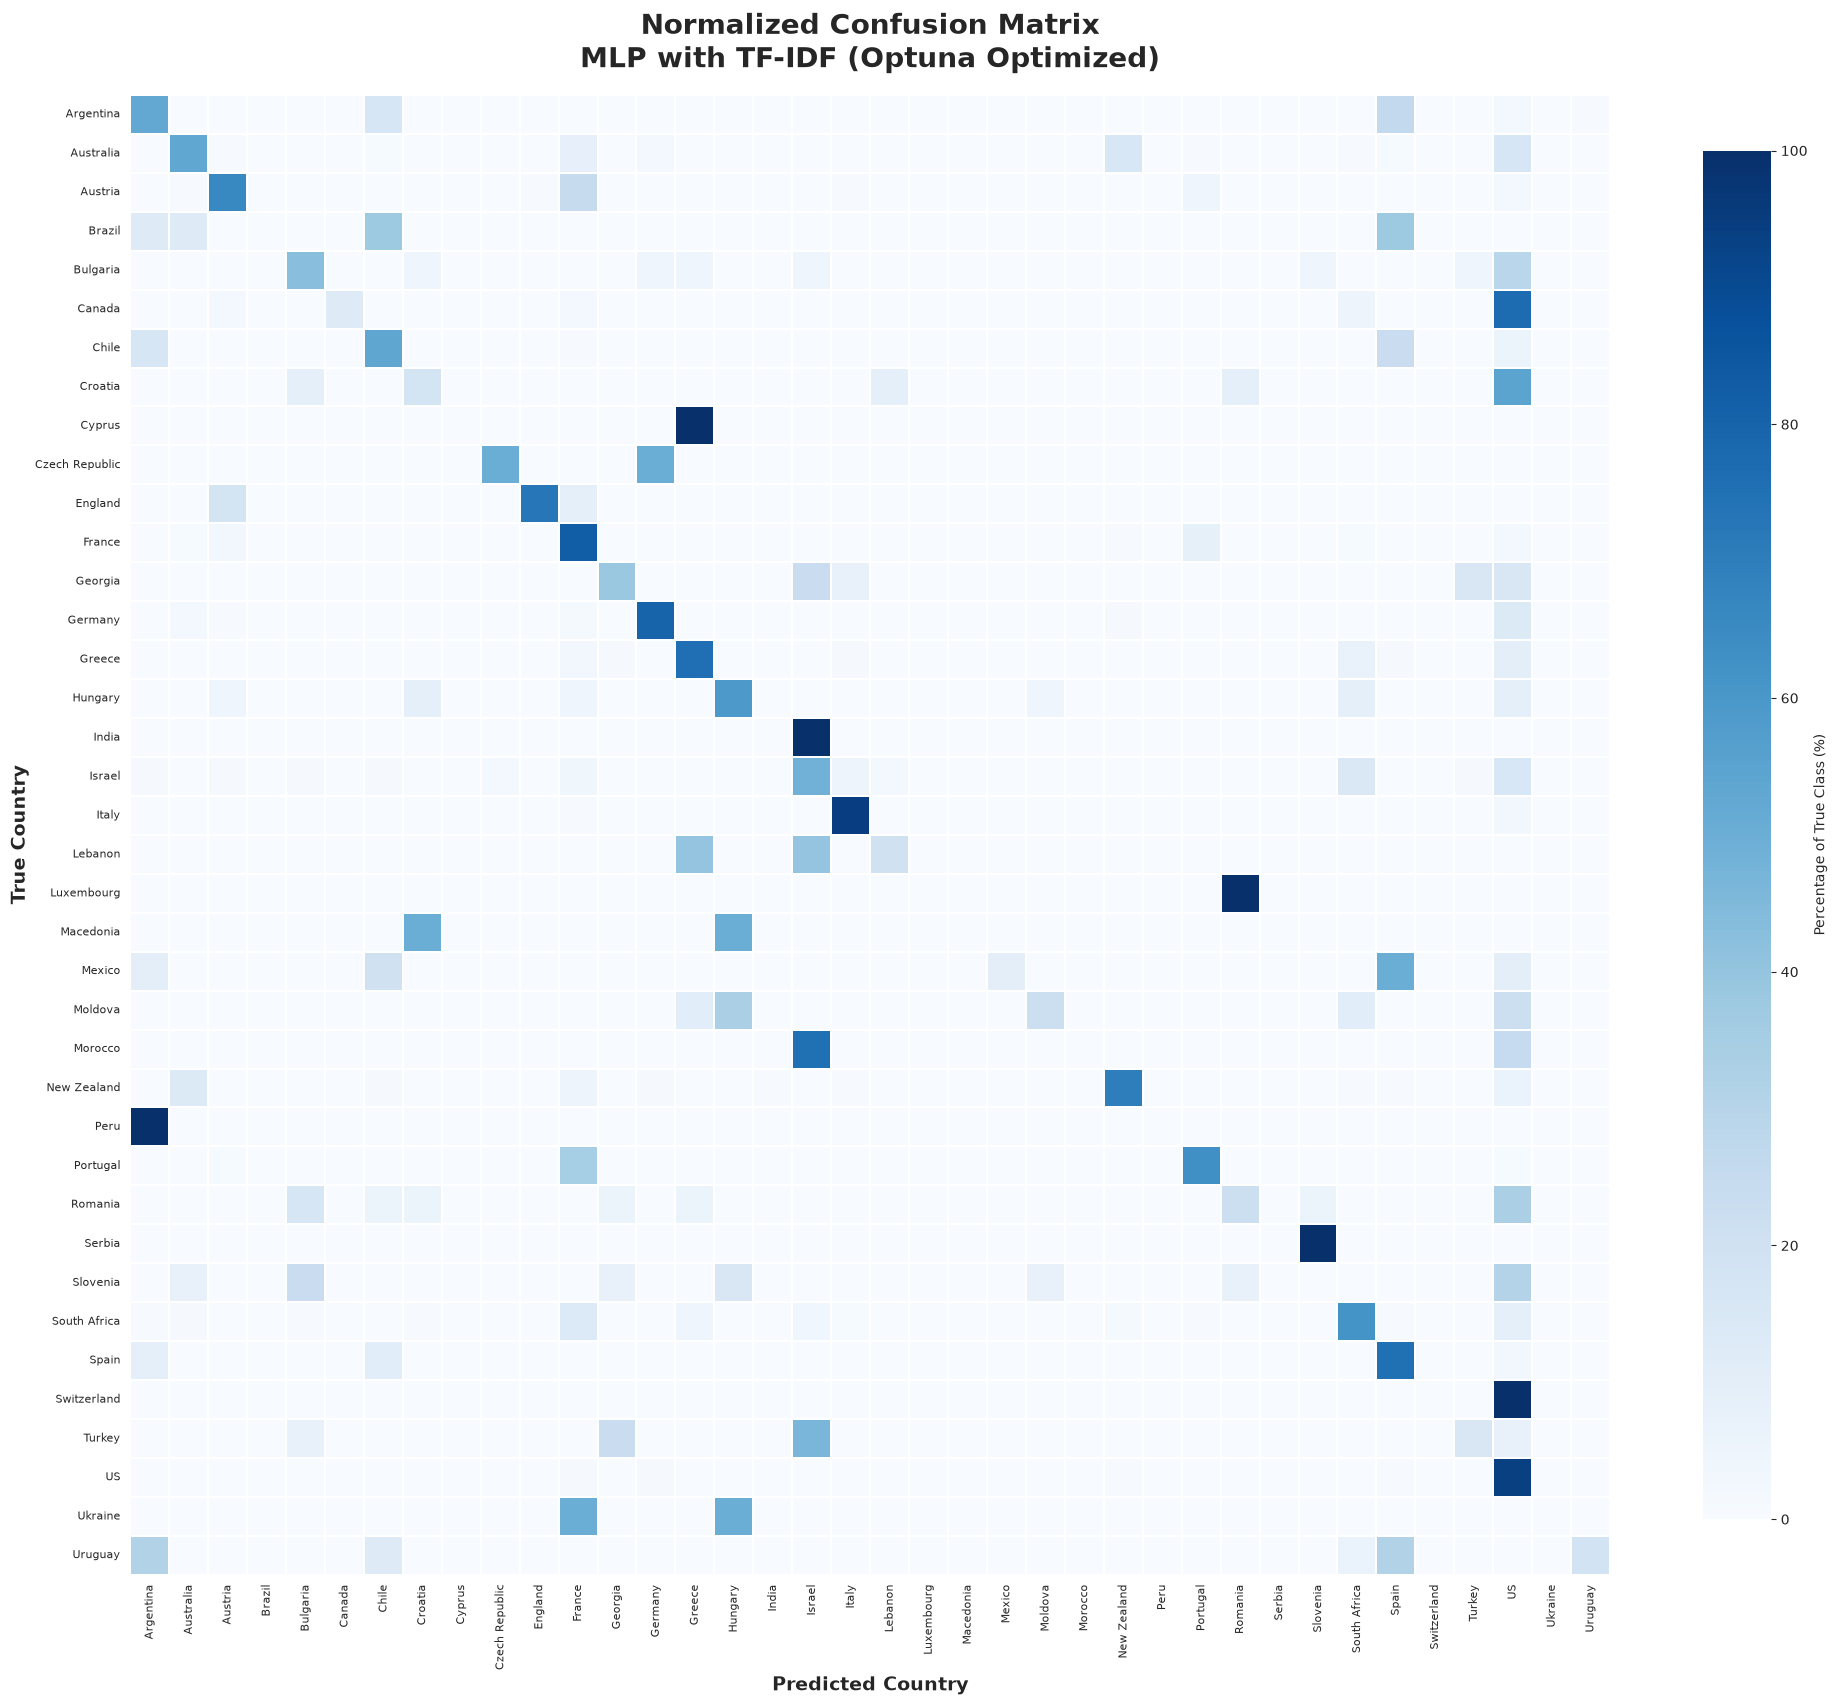

In [45]:
# ============================================================
# 38-Class Confusion Matrix
# ============================================================

# Class IDs
class_labels = np.arange(n_classes)

# Country/class names
class_names = label_encoder.inverse_transform(class_labels)

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=class_labels
)

# Row-normalized confusion matrix (%)
row_sums = cm.sum(axis=1, keepdims=True)

cm_percent = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
) * 100

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(20, 18))

ax = sns.heatmap(
    cm_percent,
    cmap='Blues',
    annot=False,
    square=True,
    linewidths=0.15,
    linecolor='white',
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=100,
    cbar_kws={
        'label': 'Percentage of True Class (%)',
        'shrink': 0.8
    }
)

plt.title(
    'Normalized Confusion Matrix\n'
    'MLP with TF-IDF (Optuna Optimized)',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Predicted Country',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    'True Country',
    fontsize=14,
    fontweight='bold'
)

# Country names
plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()

plt.show()

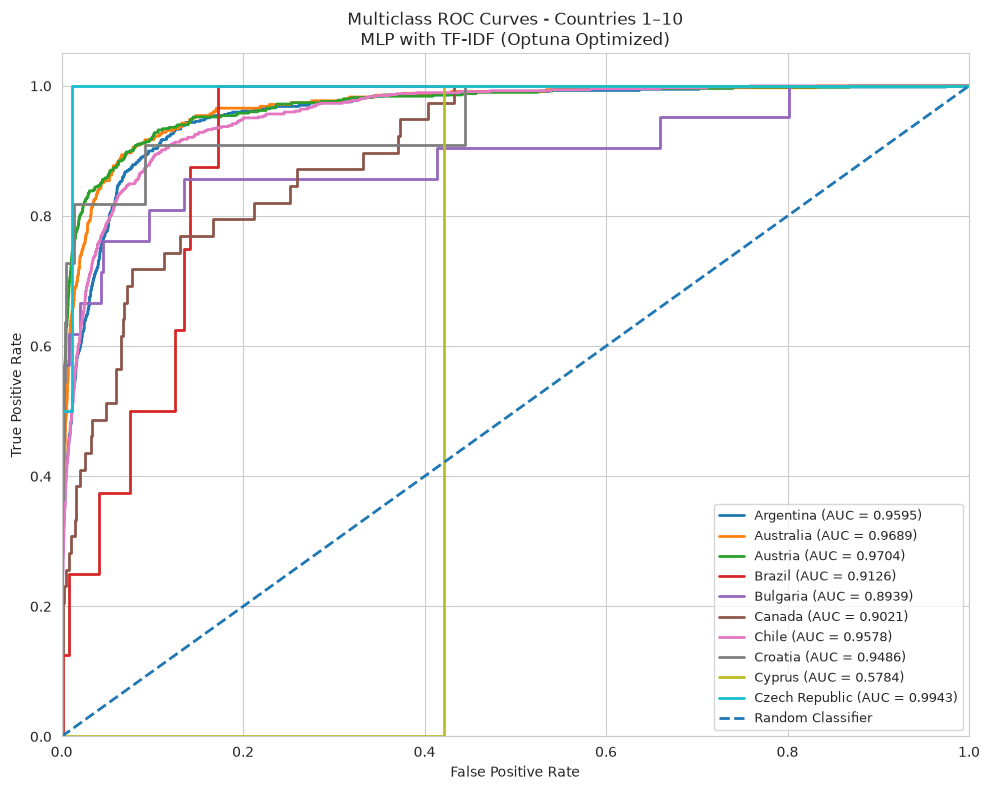

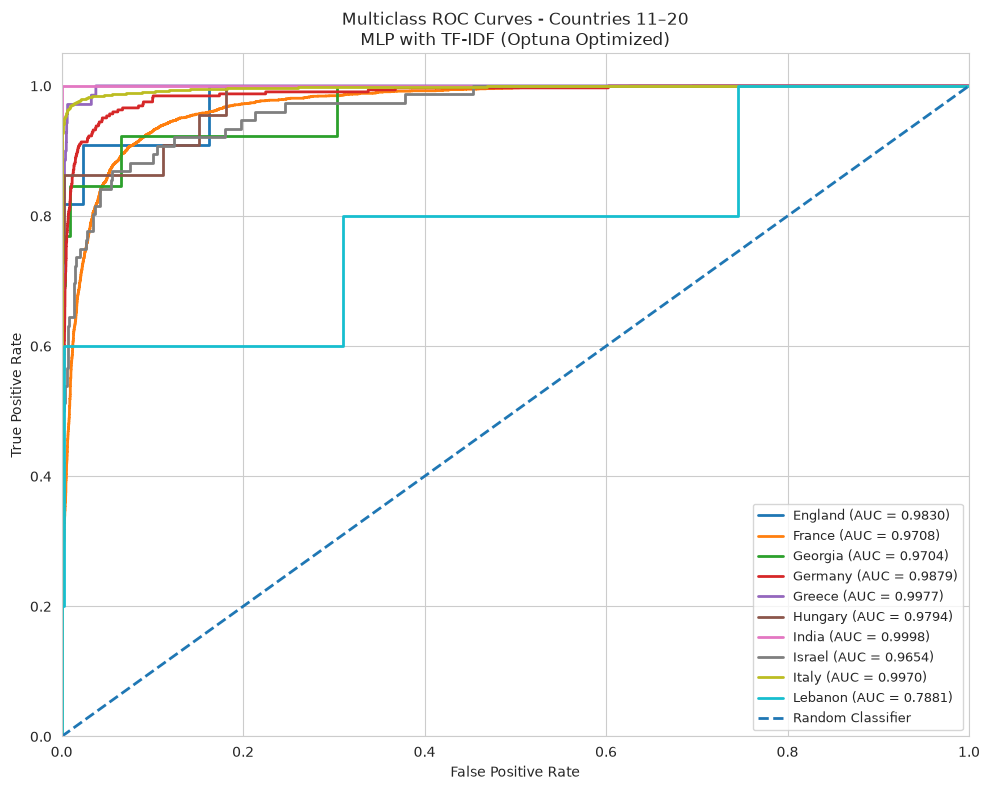

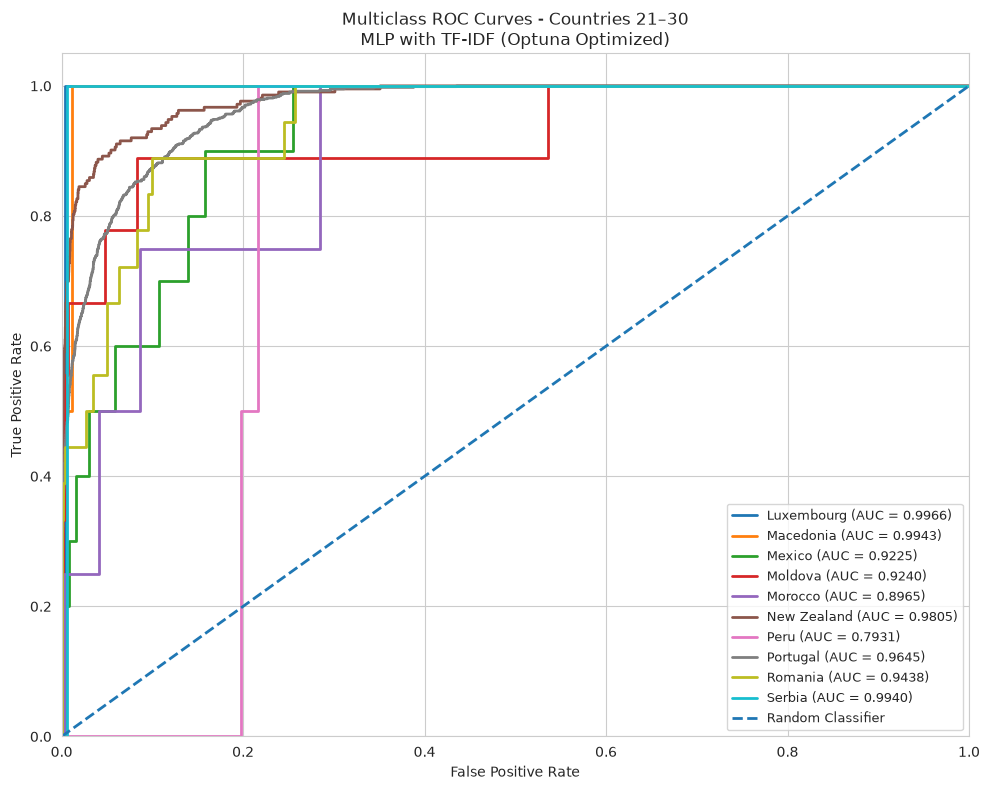

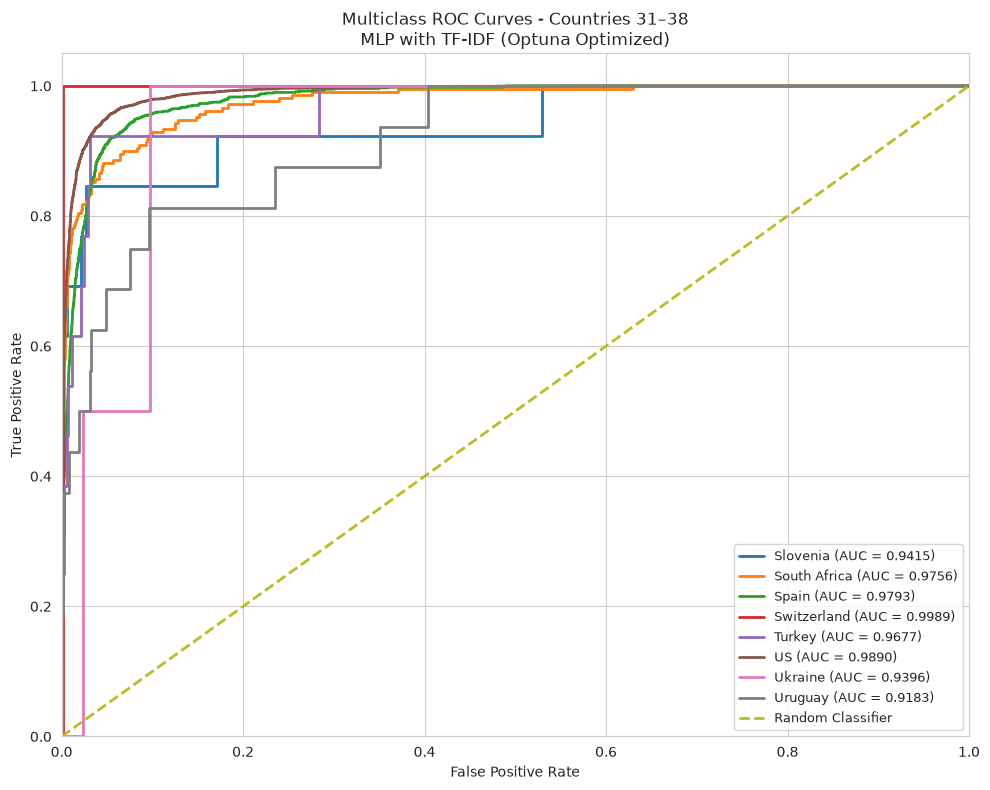

In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Get predictions and probabilities
# ============================================

mlp_tfidf_optuna.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)

        outputs = mlp_tfidf_optuna(features)

        # Probability for every country/class
        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Number of classes/countries
n_classes = all_probs.shape[1]

# ============================================
# Convert labels to one-hot
# ============================================

y_test_bin = label_binarize(
    all_labels,
    classes=np.arange(n_classes)
)

# ============================================
# Create ROC curves
# ============================================

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        all_probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# ============================================
# Plot 10 countries per graph
# ============================================

countries_per_graph = 10

for start in range(0, n_classes, countries_per_graph):

    end = min(
        start + countries_per_graph,
        n_classes
    )

    plt.figure(figsize=(10, 8))

    for i in range(start, end):

        country_name = label_encoder.inverse_transform([i])[0]

        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f'{country_name} (AUC = {roc_auc[i]:.4f})'
        )

    # Random classifier
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        lw=2,
        label='Random Classifier'
    )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    graph_number = (start // countries_per_graph) + 1

    plt.title(
        f'Multiclass ROC Curves - Countries '
        f'{start + 1}–{end}\n'
        f'MLP with TF-IDF (Optuna Optimized)'
    )

    plt.legend(
        loc='lower right',
        fontsize=9
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()